### Build a Basic Chatbot with Langgraph(GRAPH API) 

In [1]:
from typing import Annotated
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


In [2]:
class State(TypedDict):
    # messages have the type "list". the add_messages function
    # in the annotation defines how this state key should be updated
    # (In this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]
    
    
graph_builder = StateGraph(State)

In [3]:
graph_builder

In [4]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="openai/gpt-oss-120b",
)

In [6]:
# Node Functionality

def chatbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}


In [7]:
graph_builder = StateGraph(State)
# node
graph_builder.add_node("llmchatbot",chatbot)
#edge
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot",END)


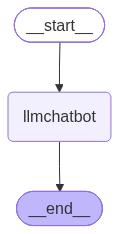

In [8]:
# compile the graph

graph = graph_builder.compile()
graph

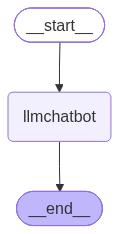

In [9]:
## visualize the graph 
from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))

except Exception:
    pass



In [10]:
response = graph.invoke({"messages":"hi"}) #type:ignore
print(response['messages'][-1].content)

Hello! How can I help you today?


In [11]:
for event in graph.stream({"messages":"Hi How are you?"}): #type:ignore
    for value in event.values():
        print(value['messages'][-1].content)

Hello! I'm doing well, thank you. How can I help you today?


## Chatbot with Tool

In [12]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

tool.invoke("What is langgraph?")

{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian C

In [13]:
# custom function

def multiply(a:int,b:int)-> int:
    """ 
    Multiply A and B
    """
    
    return a*b

tools=[tool,multiply]

In [14]:
llm_with_tool = llm.bind_tools(tools) #type:ignore


In [15]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.17'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001D2B22C57F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001D2B22C6270>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, a

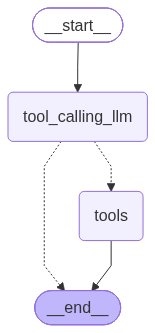

In [16]:
## StateGraph 

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition 

def tool_calling_llm(state:State): #type:ignore
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph 

builder = StateGraph(State) #type:ignore
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


## add edge 
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
    
)
builder.add_edge("tools",END)

# compile the Graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png())) #type:ignore

In [17]:
response = graph.invoke({"messages":"What is the recent ai news"})
print(response['messages'][-1].content)

{"query": "latest AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/advisor/home-equity/current-home-equity-interest-rates-09-23-26/", "title": "Latest HELOC & Home Equity Loan Rates: September 23, 2026 - Forbes", "score": 1.0, "published_date": "Wed, 23 Sep 2026 10:00:40 GMT", "content": "*   greenhouse Insights: How AI Can Help You Make Your Smartest Hire Yet| Paid Program. *    Latest HELOC & Home Equity Loan Rates: September 23, 2026. Rates were mixed today for homeowners looking to borrow against their home equity using a home equity line of credit (HELOC) or home equity loan. You can utilize your home’s equity without paying off your home in full, whether through a home equity loan or a home equity line of credit (HELOC). Image 50: Today’s HELOC & Home Equity Loan Rates: September 11, 2026 ##### Today’s HELOC & Home Equity Loan Rates: September 11, 2026 Home equity loans and home equity lines of credit 

In [18]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_ee4a598d-5bbe-4167-8e71-881a7e0f8041)
 Call ID: fc_ee4a598d-5bbe-4167-8e71-881a7e0f8041
  Args:
    query: latest AI news September 2026
    search_depth: fast
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/advisor/home-equity/current-home-equity-interest-rates-09-23-26/", "title": "Latest HELOC & Home Equity Loan Rates: September 23, 2026 - Forbes", "score": 1.0, "published_date": "Wed, 23 Sep 2026 10:00:40 GMT", "content": "*   greenhouse Insights: How AI Can Help You Make Your Smartest Hire Yet| Paid Program. *    Latest HELOC & Hom

In [19]:
response = graph.invoke({"messages":"what is the 5 multiply by 3"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the 5 multiply by 3
================================== Ai Message ==================================

5 × 3 = 15.


### ReAct Agent Architecture

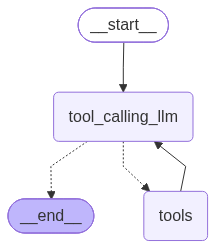

In [20]:
## StateGraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State): #type:ignore
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)#type:ignore
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
response=graph.invoke({"messages":"Give me the recent ai news and then give me  multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then give me  multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_866adcee-7397-4975-aa79-6df36649e415)
 Call ID: fc_866adcee-7397-4975-aa79-6df36649e415
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://kanerika.com/blogs/recent-developments-in-ai", "title": "Recent Developments in AI: What's Shaping 2026 - Kanerika", "content": "### Ready to Put These AI Developments to Work?\n\nPartner with Kanerika today.\n\nBook a Meeting\n\n## FAQs\n\n### What are the most recent developments in AI?\n\nThe most visible shift in 2026 is consolidation. Frontier mode

### Adding Memory in Agentic Graph

In [22]:
response = graph.invoke({"messages":"Hello my name is Jayendra"})
for n in response['messages']:
    n.pretty_print()

================================ Human Message =================================

Hello my name is Jayendra
================================== Ai Message ==================================

Hello, Jayendra! Nice to meet you. How can I assist you today?


In [ ]:
response = graph.invoke({"messages":"What is my name"}) #type:ignore
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don’t have any information about your name. If you’d like me to address you personally, just let me know what you’d like to be called!


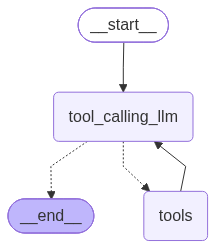

In [25]:
## StateGraph

from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# node define 
def tool_calling_llm(state=State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]} #type:ignore

# graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# create graph edge

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

#compile graph 
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))


In [29]:
config = {"configurable":{"thread_id":"1"}}

response = graph.invoke({"messages":"Hi my name is jayendra"},config=config) #type:ignore

response

{'messages': [HumanMessage(content='Hi my name is jayendra', additional_kwargs={}, response_metadata={}, id='d6bea2ac-e069-4020-9c22-787f21209de5'),
  AIMessage(content='Hello Jayendra! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hi my name is jayendra". Likely a greeting. We should respond politely, maybe ask how can help. No need for external tools.'}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 342, 'total_tokens': 401, 'completion_time': 0.123933246, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.016295101, 'prompt_tokens_details': None, 'queue_time': 0.335235617, 'total_time': 0.140228347}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_47082602e2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0d1e3-55a2-76e3-8a4f-10b4094f9fec-0', tool_calls=[], invalid_tool_calls=[], usage_metadat

In [30]:
response['messages'][-1].content

'Hello Jayendra! Nice to meet you. How can I assist you today?'

In [32]:
response = graph.invoke({"messages":"What is my name"}, config=config) #type:ignore
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi my name is jayendra
================================== Ai Message ==================================

Hello Jayendra! Nice to meet you. How can I assist you today?
================================ Human Message =================================

What is my name
================================== Ai Message ==================================

Your name is Jayendra.


In [33]:
response = graph.invoke({"messages":"Hey do you remember my name ?"}, config=config) #type:ignore
print(response["messages"][-1].content)

Yes, I remember—your name is Jayendra. How can I help you today?


### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [34]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [35]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

    

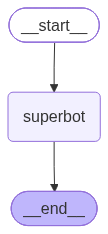

In [36]:
# create graph 
graph = StateGraph(State)

## node 

graph.add_node("superbot",superbot)

# create edge
graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)

graph_builder = graph.compile(checkpointer=memory)

# Display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [37]:
config = {"configurable":{"thread_id":"1"}} 
response = graph_builder.invoke({"messages":"Hi, my name is jayendra and i like cricket"}, config=config) #type:ignore

In [38]:
response

{'messages': [HumanMessage(content='Hi, my name is jayendra and i like cricket', additional_kwargs={}, response_metadata={}, id='e4914e73-d502-4a57-9d4b-2c4a27370e61'),
  AIMessage(content='Hey Jayendra! Nice to meet you. 🎉\n\nCricket’s such a thrilling sport—whether you’re into the fast‑paced excitement of T20, the strategic depth of Test cricket, or the balanced drama of ODIs, there’s always something to love. Do you have a favorite team, player, or format? Maybe a memorable match that’s stuck with you? I’d love to hear more about what makes cricket special for you!', additional_kwargs={'reasoning_content': 'The user says: "Hi, my name is jayendra and i like cricket". Likely they want a response. There\'s no disallowed content. Just respond friendly, perhaps ask about cricket preferences. Use a friendly tone.'}, response_metadata={'token_usage': {'completion_tokens': 146, 'prompt_tokens': 82, 'total_tokens': 228, 'completion_time': 0.302527268, 'completion_tokens_details': {'reasonin

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [45]:
config = {"configurable":{"thread_id":"3"}}
for chunk in graph_builder.stream({"messages":"Hy,My name is jayendra and I kine cricket"},config,stream_mode="updates"): #type:ignore
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Hi Jayendra! 👋 Great to meet you. I hear you’re into cricket—awesome!  \n\nDo you have a favorite team or player you follow? Are you more into the fast‑bowling action, the spin wizardry, or maybe the batting fireworks? Let me know what you enjoy most about the game, and we can chat about matches, stats, upcoming tournaments, or anything else cricket‑related you’d like!', additional_kwargs={'reasoning_content': 'The user says: "Hy,My name is jayendra and I kine cricket". Likely they want to chat about cricket. They introduced themselves. We need to respond in a friendly manner, maybe ask about their interest, favorite team, etc. Keep it conversational. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 155, 'prompt_tokens': 82, 'total_tokens': 237, 'completion_time': 0.323909891, 'completion_tokens_details': {'reasoning_tokens': 59}, 'prompt_time': 0.003274186, 'prompt_tokens_details': None, 'queue_time': 0.35111291

In [46]:
config = {"configurable":{"thread_id":"3"}}
for chunk in graph_builder.stream({"messages":"Hy,My name is jayendra and I kine cricket"},config,stream_mode="values"): #type:ignore
    print(chunk)

{'messages': [HumanMessage(content='Hy,My name is jayendra and I kine cricket', additional_kwargs={}, response_metadata={}, id='74b2e8d9-27c3-4086-b7eb-1bc1696b3d39'), AIMessage(content='Hi Jayendra! 👋 Great to meet you. I hear you’re into cricket—awesome!  \n\nDo you have a favorite team or player you follow? Are you more into the fast‑bowling action, the spin wizardry, or maybe the batting fireworks? Let me know what you enjoy most about the game, and we can chat about matches, stats, upcoming tournaments, or anything else cricket‑related you’d like!', additional_kwargs={'reasoning_content': 'The user says: "Hy,My name is jayendra and I kine cricket". Likely they want to chat about cricket. They introduced themselves. We need to respond in a friendly manner, maybe ask about their interest, favorite team, etc. Keep it conversational. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 155, 'prompt_tokens': 82, 'total_tokens': 237, 'completion_time': 0.32390989

In [47]:
# create a thread
config = {"configurable":{"thread_id":"4"}}
for chunk in graph_builder.stream({"messages":"Hy,My name is jayendra and I kine cricket"},config,stream_mode="updates"): #type:ignore
    print(chunk)

{'superbot': {'messages': [AIMessage(content="Hey Jayendra! Nice to meet you. 😊  \n\nSo you’re into cricket—awesome! Do you have a favorite team or player? Are you more into watching the big international matches, following a domestic league, or even playing the game yourself? Let me know what you’d like to chat about—whether it’s recent scores, classic moments, tactics, or anything else cricket‑related. I'm happy to dive in!", additional_kwargs={'reasoning_content': 'We need to respond. The user says: "Hy,My name is jayendra and I kine cricket". Likely they meant "I like cricket". Probably they want to talk about cricket. We should greet, ask about preferences, maybe discuss cricket. Follow policy: normal conversation. No disallowed content. We\'ll respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 161, 'prompt_tokens': 82, 'total_tokens': 243, 'completion_time': 0.332322938, 'completion_tokens_details': {'reasoning_tokens': 67}, 'prompt_time': 0.003081609, '

In [48]:
for chunk in graph_builder.stream({"messages":"I also |like football"},config,stream_mode="values"): #type:ignore
    print(chunk)

{'messages': [HumanMessage(content='Hy,My name is jayendra and I kine cricket', additional_kwargs={}, response_metadata={}, id='452f815b-3c03-4c9c-a1ee-12df37dfb79b'), AIMessage(content="Hey Jayendra! Nice to meet you. 😊  \n\nSo you’re into cricket—awesome! Do you have a favorite team or player? Are you more into watching the big international matches, following a domestic league, or even playing the game yourself? Let me know what you’d like to chat about—whether it’s recent scores, classic moments, tactics, or anything else cricket‑related. I'm happy to dive in!", additional_kwargs={'reasoning_content': 'We need to respond. The user says: "Hy,My name is jayendra and I kine cricket". Likely they meant "I like cricket". Probably they want to talk about cricket. We should greet, ask about preferences, maybe discuss cricket. Follow policy: normal conversation. No disallowed content. We\'ll respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 161, 'prompt_tokens': 

In [ ]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"): #type:ignore
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a0d200-d98b-71f2-94b4-87d22d4ac639', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='048ceb25-21f8-4643-8fd9-ecb83674b6f3')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '01a0d200-d9a8-7741-a8ed-fb6e2372fc79', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:492f4d78-8afe-5c78-10f3-453cf2946149'}, 'parent_ids': ['01a0d200-d98b-71f2-94b4-87d22d4ac639']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':